# Salary Prediction using Polynomial Regression

## Task 1: Data Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
data = pd.read_csv("Position_Salaries.csv")
data

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


In [3]:
data.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


### Input Feature

Level

### Target Variable

Salary

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Position  10 non-null     str  
 1   Level     10 non-null     int64
 2   Salary    10 non-null     int64
dtypes: int64(2), str(1)
memory usage: 372.0 bytes


In [5]:
data.describe()

,Level,Salary
count,10.00000,10.000000
mean,5.50000,249500.000000
std,3.02765,299373.883668
min,1.00000,45000.000000
25%,3.25000,65000.000000
50%,5.50000,130000.000000
75%,7.75000,275000.000000
max,10.00000,1000000.000000


## Task 2: Data Preprocessing

In [6]:
data.isnull().sum()

Position    0
Level       0
Salary      0
dtype: int64

In [7]:
X = data.iloc[:, 1:2]
y = data.iloc[:, 2]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (8, 1)
Testing Data Shape: (2, 1)


## Task 3: Model Development

In [10]:
poly = PolynomialFeatures(degree=3)

In [11]:
X_train_poly = poly.fit_transform(X_train)

In [12]:
X_test_poly = poly.transform(X_test)

In [13]:
model = LinearRegression()

In [14]:
model.fit(X_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 0. ,157144.24,-44274.84, 3925.87]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-8.366e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](4,)","[894.35, 15.36, 0.66, 0. ]"


In [15]:
y_pred = model.predict(X_test_poly)

In [16]:
y_pred

array([606335.60051157,  84934.89129171])

## Task 4: Model Evaluation

In [17]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 70635.24590164087


In [18]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 6263853282.860252


In [19]:
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.8762695647830073


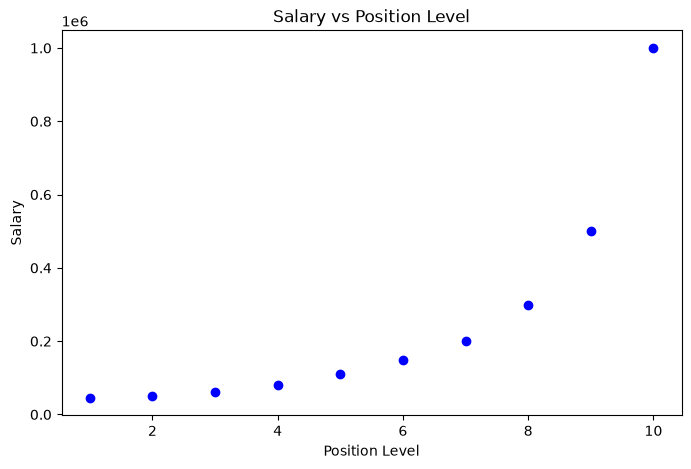

In [20]:
plt.figure(figsize=(8,5))

plt.scatter(X, y, color="blue")

plt.xlabel("Position Level")

plt.ylabel("Salary")

plt.title("Salary vs Position Level")

plt.savefig("salary_prediction.png")

plt.show()

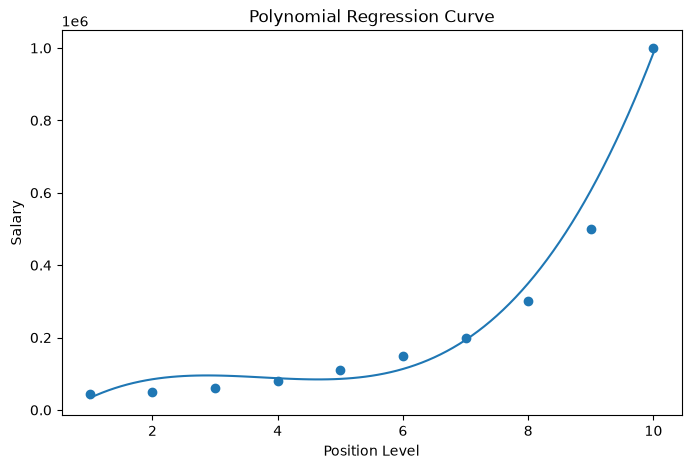

In [26]:
X_grid = np.arange(X["Level"].min(), X["Level"].max() + 0.1, 0.1)

X_grid = pd.DataFrame(X_grid, columns=["Level"])

plt.figure(figsize=(8,5))

plt.scatter(X["Level"], y)

plt.plot(
    X_grid["Level"],
    model.predict(poly.transform(X_grid))
)

plt.xlabel("Position Level")

plt.ylabel("Salary")

plt.title("Polynomial Regression Curve")

plt.savefig("polynomial_regression.png")

plt.show()

In [27]:
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Absolute Error: 70635.24590164087
Mean Squared Error: 6263853282.860252
R2 Score: 0.8762695647830073


## Observations

1. The Polynomial Regression model captured the relationship between position level and salary effectively.

2. The model achieved an R² score of 0.8763, indicating good prediction performance on the test data.

3. The polynomial regression curve follows the trend of the original data more closely than a straight line.

## Task 5: Conclusion

Polynomial Regression was used to predict employee salaries based on position level. The model successfully captured the non-linear relationship between the input feature and salary. The evaluation results showed good performance with an R² score of 0.8763, indicating that the model explains most of the variation in salary values. Unlike Linear Regression, which fits only a straight line, Polynomial Regression can fit curved relationships and provide more accurate predictions for non-linear datasets. For this dataset, Polynomial Regression is a better choice because it closely follows the salary trend across different position levels and improves prediction accuracy.